## DP2‑VAE (paper‑style) for Brain Tumor dataset

This notebook implements the **training mechanism** from *DP2‑VAE: Differentially Private Pre‑trained Variational Autoencoders* (Jiang et al., 2022):

- **Stage 1 (Algorithm 1)**: Partition private dataset into **K disjoint subsets**. For each subset, **initialize encoder+decoder**, train on that subset, and **keep the encoder**.
- **Stage 2 (Algorithm 2)**: **Reinitialize decoder**. For each training step, pick an encoder/subset index **k ~ Uniform(1..K)**, sample a minibatch from subset `D_k`, update **encoder_k non‑privately**, and update the **decoder with DP (clipping + Gaussian noise)**.

**Important**: This matches the *mechanism* in the paper (what is and isn’t privatized). The exact CNN layer widths in the paper are reported for MNIST/FashionMNIST/CelebA; for brain MRI we use a compact 64×64 conditional VAE architecture that’s stable on this dataset.

Only the **decoder** is intended to be released.



In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

from data_loader.brain_tumor import BrainTumorDataset

# -------------------- reproducibility --------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print("device:", DEVICE)



device: mps


In [2]:
# -------------------- config (paper mechanism) --------------------
# K encoders/subsets. Paper uses very large K; for this dataset size we use a smaller K.
K = 20
BATCH_SIZE = 16
IMG_SIZE = 64
LATENT_DIM = 16
LABEL_EMB_DIM = 8

# Stage 1 (Algorithm 1) pretraining
STAGE1_EPOCHS = 20
STAGE1_LR = 1e-3
CLIP_C = 1.0  # gradient norm clip bound C (paper clips gradients)

# Loss scaling (important for DP SNR)
# If recon loss is averaged per-pixel, gradients can be tiny and DP noise dominates.
# Paper ELBO uses a log-likelihood that effectively SUMS over pixels.
# For MRI-like continuous intensities, MSE tends to behave better than BCE.
RECON_LOSS = "mse"         # "mse" | "bce"
RECON_REDUCTION = "sum"    # "sum" recommended here

# KL weighting
# - Stage 1: keep KL lighter so each encoder learns good recon features on its subset
# - Stage 2: anneal KL up to encourage q(z|x,y) -> N(0,I) (better PRIOR samples)
BETA_KL_STAGE1 = 0.1
BETA_KL_STAGE2_MAX = 1.0
KL_WARMUP_STEPS = 4000

# Stage 2 (Algorithm 2)
# Note: 20000 steps will take noticeably longer than 2000.
STAGE2_STEPS = 20000         # iterations t=1..T (paper uses iterations, not epochs)
STAGE2_LR_DEC = 1e-3         # decoder LR (η)
STAGE2_LR_ENC = 1e-3         # encoder LR

# DP noise (σ). Lower σ improves utility but weakens privacy.
NOISE_MULTIPLIER = 0.3
DEBUG_NOISE_MULTIPLIER = None  # set to 0.0 for a no-noise sanity check

# Encoder updates are non-private in DP2-VAE; don't clip them unless you need stability.
ENCODER_GRAD_CLIP = None  # set to a float (e.g. 1.0) to enable

# IMPORTANT:
# In Stage 2 we compute gradients from a batch-AVERAGED loss (loss_vec.mean()).
# For DP-SGD on the average gradient, the noise std should scale like (σ*C/BATCH_SIZE).
# (equivalently: add noise σ*C to the SUM gradient and then divide by BATCH_SIZE).
NOISE_ON_AVG_GRAD = True

# Dataset
DATA_ROOT = "../data/brain_tumor_dataset"

print({
    "K": K,
    "batch": BATCH_SIZE,
    "latent_dim": LATENT_DIM,
    "stage1_epochs": STAGE1_EPOCHS,
    "stage2_steps": STAGE2_STEPS,
    "clip_C": CLIP_C,
    "noise_multiplier_sigma": NOISE_MULTIPLIER,
})



{'K': 20, 'batch': 16, 'latent_dim': 16, 'stage1_epochs': 20, 'stage2_steps': 20000, 'clip_C': 1.0, 'noise_multiplier_sigma': 0.3}


In [3]:
# -------------------- load dataset --------------------
full_ds = BrainTumorDataset(root=DATA_ROOT)
N = len(full_ds)
print("N=", N, "class_counts=", {0: full_ds.targets.count(0), 1: full_ds.targets.count(1)})

# Make sure K isn't so large that subsets are smaller than a batch (would yield 0 batches).
# (paper uses huge K on huge datasets; for small datasets we must cap K)
K = int(min(K, max(1, N // BATCH_SIZE)))
print("Using K=", K)

# Partition into K disjoint subsets (paper: shuffle and subsample without replacement)
perm = torch.randperm(N)
subsets = torch.chunk(perm, K)  # roughly equal sized

# Build a dataloader per subset D_k
subset_loaders = []
subset_num_batches = []
for k, idxs in enumerate(subsets):
    ds_k = Subset(full_ds, idxs.tolist())
    # drop_last=False avoids producing 0 batches for small subsets
    dl_k = DataLoader(ds_k, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    subset_loaders.append(dl_k)
    subset_num_batches.append(len(dl_k))

print("subset sizes:", [len(s) for s in subsets])
print("subset #batches:", subset_num_batches)



N= 253 class_counts= {0: 98, 1: 155}
Using K= 15
subset sizes: [17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 15]
subset #batches: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1]


In [4]:
# -------------------- conditional VAE --------------------
class CondEncoder(nn.Module):
    def __init__(self, latent_dim: int, label_emb_dim: int):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1)
        self.gn1 = nn.GroupNorm(8, 32)
        self.gn2 = nn.GroupNorm(8, 64)
        self.gn3 = nn.GroupNorm(8, 128)

        self.flatten_dim = 128 * (IMG_SIZE // 8) * (IMG_SIZE // 8)
        self.label_emb = nn.Embedding(2, label_emb_dim)
        self.fc_mu = nn.Linear(self.flatten_dim + label_emb_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim + label_emb_dim, latent_dim)

    def forward(self, x, y):
        h = F.leaky_relu(self.gn1(self.conv1(x)))
        h = F.leaky_relu(self.gn2(self.conv2(h)))
        h = F.leaky_relu(self.gn3(self.conv3(h)))
        h = h.view(h.size(0), -1)
        yemb = self.label_emb(y)
        h = torch.cat([h, yemb], dim=1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class CondDecoder(nn.Module):
    def __init__(self, latent_dim: int, label_emb_dim: int):
        super().__init__()
        self.label_emb = nn.Embedding(2, label_emb_dim)
        self.filters = 128
        self.reshape_dim = IMG_SIZE // 8
        self.fc = nn.Linear(latent_dim + label_emb_dim, self.filters * self.reshape_dim * self.reshape_dim)
        self.deconv1 = nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1)
        self.deconv3 = nn.ConvTranspose2d(32, 3, 3, 2, 1, output_padding=1)
        self.gn1 = nn.GroupNorm(8, 64)
        self.gn2 = nn.GroupNorm(8, 32)

    def forward(self, z, y):
        yemb = self.label_emb(y)
        zy = torch.cat([z, yemb], dim=1)
        h = self.fc(zy)
        h = h.view(-1, self.filters, self.reshape_dim, self.reshape_dim)
        h = F.leaky_relu(self.gn1(self.deconv1(h)))
        h = F.leaky_relu(self.gn2(self.deconv2(h)))
        x_hat = torch.sigmoid(self.deconv3(h))
        return x_hat


def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


def elbo_loss(x, x_hat, mu, logvar, beta_kl: float):
    # ELBO = E[log p(x|z,y)] - KL(q(z|x,y)||p(z))
    # We minimize negative ELBO: recon + beta*KL
    # IMPORTANT: using SUM over pixels makes gradients large enough to survive DP noise.

    if RECON_LOSS == "bce":
        # x_hat is already sigmoid'd
        recon_map = F.binary_cross_entropy(x_hat, x, reduction='none')
    elif RECON_LOSS == "mse":
        recon_map = F.mse_loss(x_hat, x, reduction='none')
    else:
        raise ValueError(RECON_LOSS)

    if RECON_REDUCTION == "sum":
        recon = recon_map.sum(dim=[1, 2, 3])
    elif RECON_REDUCTION == "mean":
        recon = recon_map.mean(dim=[1, 2, 3])
    else:
        raise ValueError(RECON_REDUCTION)

    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)  # per-sample

    # For logging only (normalize recon to per-pixel so numbers are interpretable)
    num_pix = float(x.shape[1] * x.shape[2] * x.shape[3])
    recon_log = (recon / num_pix).mean().item()
    kl_log = kl.mean().item()

    return recon + (beta_kl * kl), recon_log, kl_log



In [5]:
# -------------------- Stage 1 (Algorithm 1): pretrain K encoders on K disjoint subsets --------------------
# Paper: for each subset D_k, initialize encoder θ_k and decoder φ, train both on D_k, then KEEP θ_k.

encoders = []
print("\n[Stage 1] pretraining encoders...")

# Logging
stage1_logs = {
    "k": [],
    "epoch": [],
    "loss": [],
    "recon_per_pix": [],
    "kl": [],
}

for k in range(K):
    enc = CondEncoder(LATENT_DIM, LABEL_EMB_DIM).to(DEVICE)
    dec = CondDecoder(LATENT_DIM, LABEL_EMB_DIM).to(DEVICE)

    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=STAGE1_LR)

    dl = subset_loaders[k]
    for epoch in range(STAGE1_EPOCHS):
        enc.train(); dec.train()
        running = 0.0
        running_recon = 0.0
        running_kl = 0.0

        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            opt.zero_grad()
            mu, logvar = enc(x, y)
            z = reparameterize(mu, logvar)
            x_hat = dec(z, y)
            loss_vec, recon_per_pix, kl_m = elbo_loss(x, x_hat, mu, logvar, beta_kl=BETA_KL_STAGE1)
            loss = loss_vec.mean()

            loss.backward()
            # Algorithm 1 clips both encoder and decoder grads
            torch.nn.utils.clip_grad_norm_(list(enc.parameters()) + list(dec.parameters()), max_norm=CLIP_C)
            opt.step()

            running += loss.item()
            running_recon += float(recon_per_pix)
            running_kl += float(kl_m)

        denom = max(1, len(dl))
        avg_loss = running / denom
        avg_recon = running_recon / denom
        avg_kl = running_kl / denom

        stage1_logs["k"].append(k)
        stage1_logs["epoch"].append(epoch + 1)
        stage1_logs["loss"].append(avg_loss)
        stage1_logs["recon_per_pix"].append(avg_recon)
        stage1_logs["kl"].append(avg_kl)

        if (epoch + 1) % max(1, STAGE1_EPOCHS // 5) == 0:
            print(f"  k={k:02d} epoch {epoch+1:03d}/{STAGE1_EPOCHS} loss={avg_loss:.3f} recon/pix={avg_recon:.4f} kl={avg_kl:.3f}")

    # KEEP encoder, discard decoder (paper keeps θ_k only)
    encoders.append(enc.eval())

print("[Stage 1] done. encoders:", len(encoders))




[Stage 1] pretraining encoders...
  k=00 epoch 004/20 loss=1040.762 recon/pix=0.0838 kl=114.321
  k=00 epoch 008/20 loss=531.773 recon/pix=0.0421 kl=141.810
  k=00 epoch 012/20 loss=393.234 recon/pix=0.0315 kl=58.292
  k=00 epoch 016/20 loss=347.980 recon/pix=0.0280 kl=42.132
  k=00 epoch 020/20 loss=449.055 recon/pix=0.0360 kl=71.060
  k=01 epoch 004/20 loss=902.594 recon/pix=0.0726 kl=102.786
  k=01 epoch 008/20 loss=714.121 recon/pix=0.0571 kl=125.424
  k=01 epoch 012/20 loss=469.260 recon/pix=0.0378 kl=45.291
  k=01 epoch 016/20 loss=364.185 recon/pix=0.0292 kl=50.373
  k=01 epoch 020/20 loss=293.354 recon/pix=0.0232 kl=82.993
  k=02 epoch 004/20 loss=864.609 recon/pix=0.0695 kl=106.878
  k=02 epoch 008/20 loss=546.897 recon/pix=0.0437 kl=103.210
  k=02 epoch 012/20 loss=459.354 recon/pix=0.0370 kl=41.864
  k=02 epoch 016/20 loss=361.606 recon/pix=0.0290 kl=58.578
  k=02 epoch 020/20 loss=336.596 recon/pix=0.0269 kl=54.860
  k=03 epoch 004/20 loss=715.369 recon/pix=0.0574 kl=97.72

In [6]:
# -------------------- Stage 2 (Algorithm 2): DP train decoder, non-private train encoders --------------------
# Paper: reinitialize decoder φ, then for t=1..T:
#   - sample k ~ Unif(1..K)
#   - sample batch from D_k
#   - update encoder θ_k normally
#   - update decoder with clipped gradient + Gaussian noise

print("\n[Stage 2] DP training decoder, continuing to train encoders (paper mechanism)...")

# fresh decoder (paper reinitializes φ)
dec = CondDecoder(LATENT_DIM, LABEL_EMB_DIM).to(DEVICE)
dec.train()

# optimizer for decoder
opt_dec = torch.optim.Adam(dec.parameters(), lr=STAGE2_LR_DEC)

# separate optimizer per encoder (only updates when that encoder is selected)
opt_enc = [torch.optim.Adam(enc.parameters(), lr=STAGE2_LR_ENC) for enc in encoders]

# iterators per subset dataloader (so we can sample batches in a loop)
subset_iters = [iter(dl) for dl in subset_loaders]

def next_batch(k: int):
    global subset_iters
    try:
        return next(subset_iters[k])
    except StopIteration:
        subset_iters[k] = iter(subset_loaders[k])
        return next(subset_iters[k])

# bookkeeping (for curves)
k_counts = [0 for _ in range(K)]  # how often each encoder was selected (actual steps)

stage2_logs = {
    't': [],
    'k': [],
    'loss': [],
    'recon_per_pix': [],
    'kl': [],
    'grad_norm': [],
    'sigma': [],
    'beta_kl': [],
}

loss_hist = []
recon_hist = []
kl_hist = []

def log_step(t, k, loss, recon_pp, kl, grad_norm, sigma, beta_kl):
    stage2_logs['t'].append(int(t))
    stage2_logs['k'].append(int(k))
    stage2_logs['loss'].append(float(loss))
    stage2_logs['recon_per_pix'].append(float(recon_pp))
    stage2_logs['kl'].append(float(kl))
    stage2_logs['grad_norm'].append(float(grad_norm))
    stage2_logs['sigma'].append(float(sigma))
    stage2_logs['beta_kl'].append(float(beta_kl))

for t in range(1, STAGE2_STEPS + 1):
    k = random.randrange(K)  # k ~ Unif(0..K-1)
    k_counts[k] += 1
    enc_k = encoders[k]

    x, y = next_batch(k)
    x = x.to(DEVICE)
    y = y.to(DEVICE)

    # forward
    enc_k.train(); dec.train()
    mu, logvar = enc_k(x, y)
    z = reparameterize(mu, logvar)
    x_hat = dec(z, y)
    beta_t = min(BETA_KL_STAGE2_MAX, BETA_KL_STAGE2_MAX * (t / max(1, KL_WARMUP_STEPS)))
    loss_vec, recon_m, kl_m = elbo_loss(x, x_hat, mu, logvar, beta_kl=beta_t)
    loss = loss_vec.mean()

    # ---------------- encoder update (non-private)
    opt_enc[k].zero_grad()
    # backprop through encoder + decoder graph
    loss.backward(retain_graph=True)
    # only step encoder params for this k (non-private)
    if ENCODER_GRAD_CLIP is not None:
        torch.nn.utils.clip_grad_norm_(enc_k.parameters(), max_norm=float(ENCODER_GRAD_CLIP))
    opt_enc[k].step()

    # ---------------- decoder update (DP)
    # Recompute decoder grads cleanly for DP update
    opt_dec.zero_grad()
    # recompute forward for clean grads (avoids mixing with encoder step)
    mu2, logvar2 = enc_k(x, y)
    z2 = reparameterize(mu2, logvar2)
    x_hat2 = dec(z2, y)
    loss_vec2, _, _ = elbo_loss(x, x_hat2, mu2, logvar2, beta_kl=beta_t)
    loss2 = loss_vec2.mean()
    loss2.backward()

    # Algorithm 2 clips the (averaged) decoder gradient to norm C
    total_norm = torch.nn.utils.clip_grad_norm_(dec.parameters(), max_norm=CLIP_C)

    # Add Gaussian noise to decoder gradient
    sigma = NOISE_MULTIPLIER if DEBUG_NOISE_MULTIPLIER is None else float(DEBUG_NOISE_MULTIPLIER)
    # If gradients come from an averaged loss, scale noise by 1/BATCH_SIZE (DP-SGD on avg grad)
    noise_std = (sigma * CLIP_C / BATCH_SIZE) if NOISE_ON_AVG_GRAD else (sigma * CLIP_C)

    for p in dec.parameters():
        if p.grad is None:
            continue
        noise = torch.randn_like(p.grad) * noise_std
        p.grad.add_(noise)

    opt_dec.step()

    # log
    loss_hist.append(loss.item())
    recon_hist.append(recon_m)
    kl_hist.append(kl_m)

    if t % 50 == 0:
        log_step(
            t=t,
            k=k,
            loss=float(np.mean(loss_hist[-50:])),
            recon_pp=float(np.mean(recon_hist[-50:])),
            kl=float(np.mean(kl_hist[-50:])),
            grad_norm=float(total_norm),
            sigma=float(sigma),
            beta_kl=float(beta_t),
        )

    if t % 200 == 0:
        print(f"t={t:05d}/{STAGE2_STEPS}  k={k:02d}  loss={np.mean(loss_hist[-200:]):.4f}  recon/pix={np.mean(recon_hist[-200:]):.4f}  kl={np.mean(kl_hist[-200:]):.4f}  grad_norm={float(total_norm):.3f}  sigma={sigma}  noise_std={noise_std:.5f}")

print("[Stage 2] done.")
print("[Stage 2] encoder selection counts (actual steps):")
for i,c in enumerate(k_counts):
    print(f"  k={i:02d}: {c}")
print("[Stage 2] most-selected k:", int(np.argmax(k_counts)))




[Stage 2] DP training decoder, continuing to train encoders (paper mechanism)...
t=00200/20000  k=12  loss=585.7442  recon/pix=0.0469  kl=320.3654  grad_norm=193.974  sigma=0.3  noise_std=0.01875
t=00400/20000  k=12  loss=369.1647  recon/pix=0.0290  kl=181.2835  grad_norm=415.418  sigma=0.3  noise_std=0.01875
t=00600/20000  k=02  loss=333.1538  recon/pix=0.0258  kl=128.5127  grad_norm=204.826  sigma=0.3  noise_std=0.01875
t=00800/20000  k=03  loss=311.0289  recon/pix=0.0237  kl=115.8164  grad_norm=339.141  sigma=0.3  noise_std=0.01875
t=01000/20000  k=10  loss=291.6412  recon/pix=0.0221  kl=92.1562  grad_norm=115.466  sigma=0.3  noise_std=0.01875
t=01200/20000  k=11  loss=274.0044  recon/pix=0.0204  kl=83.5204  grad_norm=291.393  sigma=0.3  noise_std=0.01875
t=01400/20000  k=06  loss=276.0574  recon/pix=0.0205  kl=75.3217  grad_norm=412.892  sigma=0.3  noise_std=0.01875
t=01600/20000  k=10  loss=271.0052  recon/pix=0.0199  kl=70.8077  grad_norm=351.411  sigma=0.3  noise_std=0.01875
t=

using encoder for recon: 10


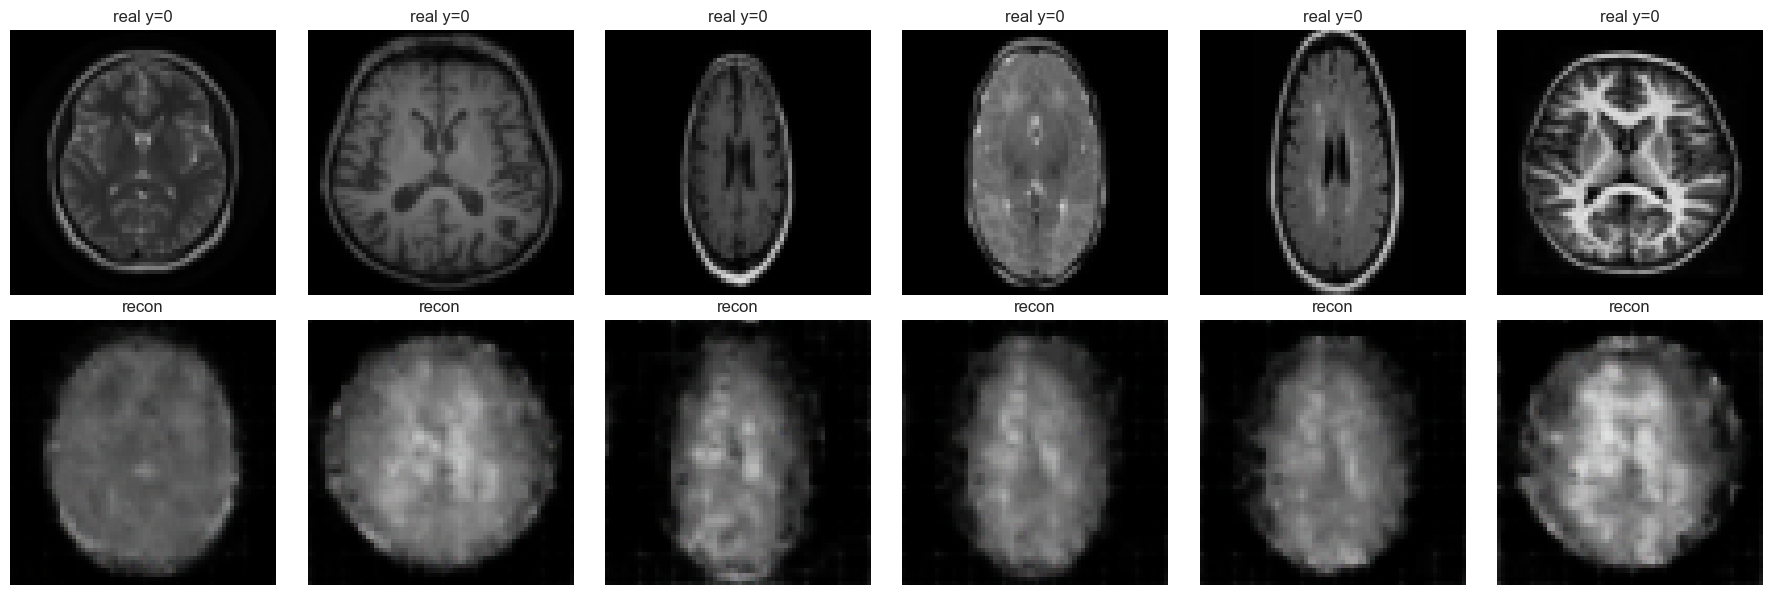

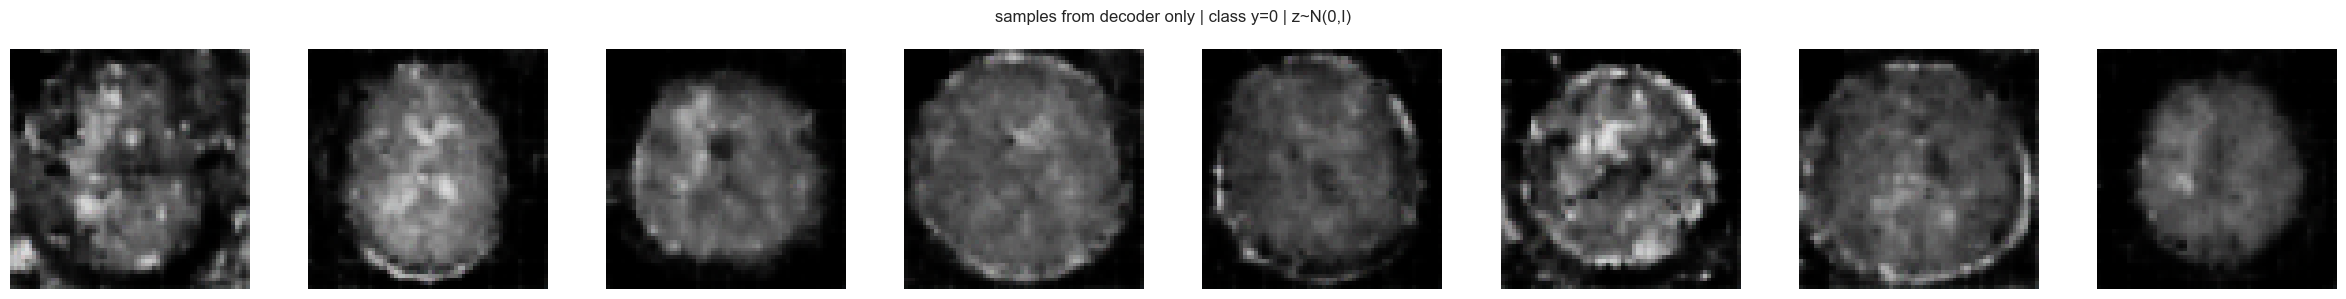

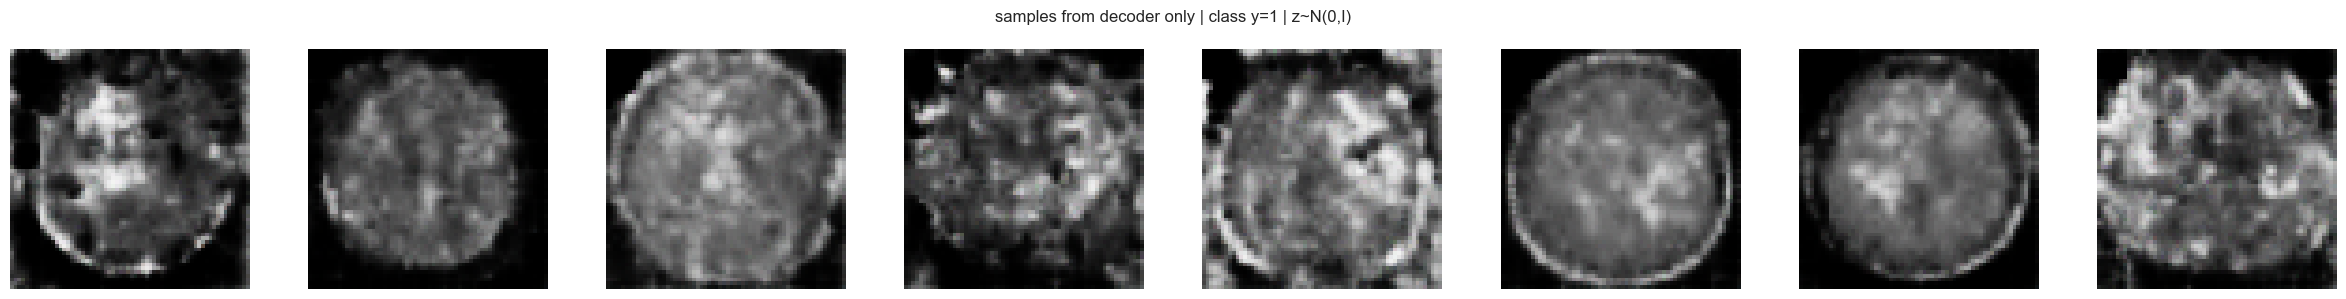

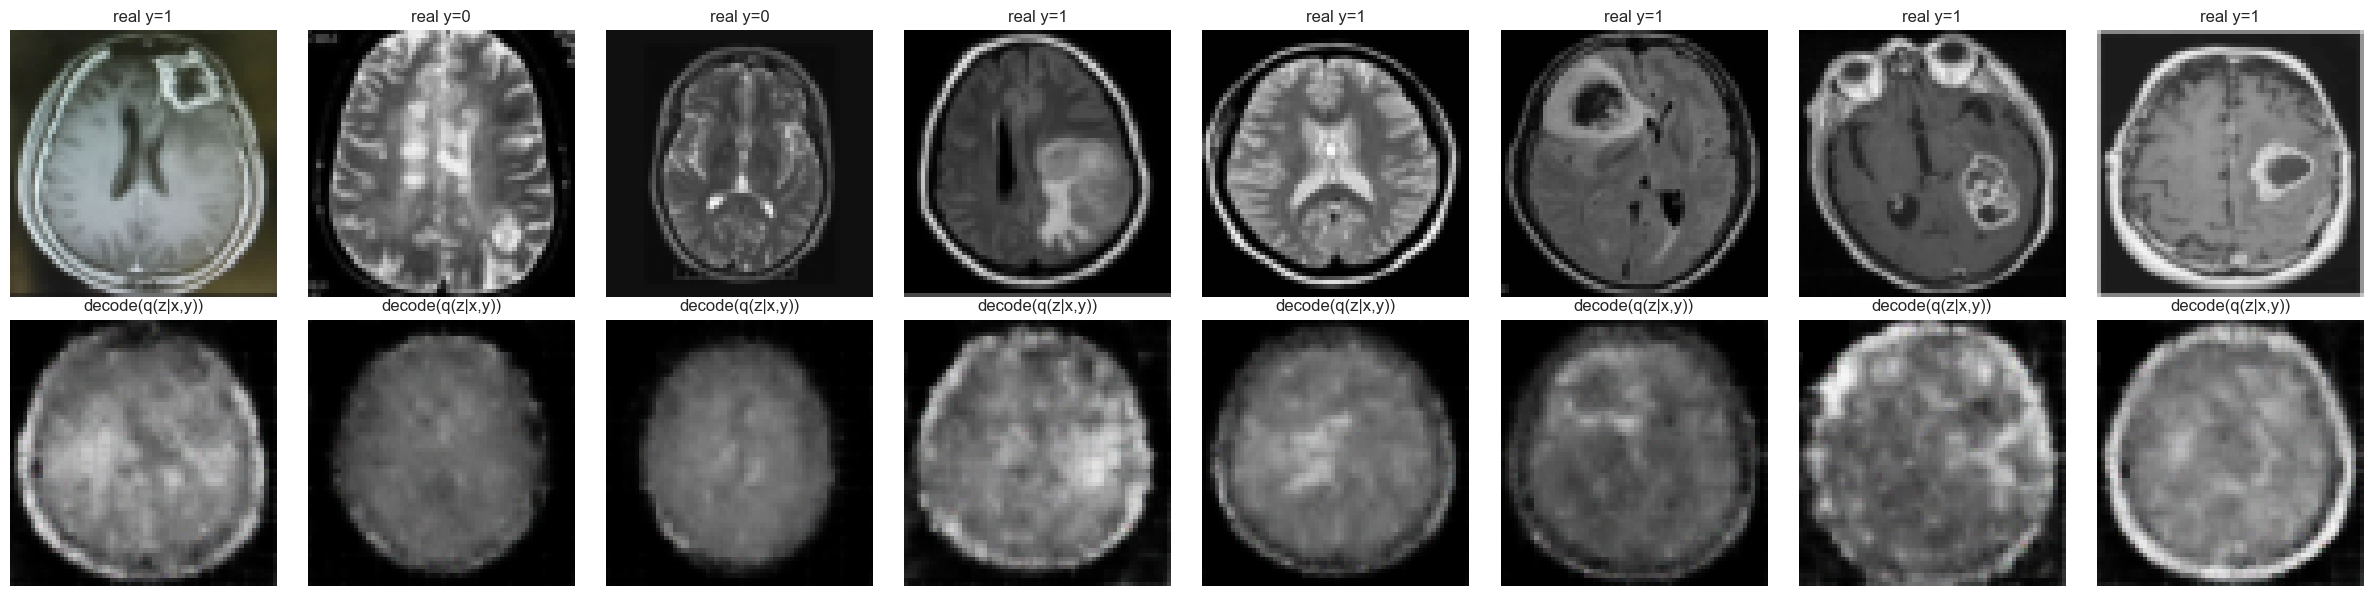

In [7]:
# -------------------- visualize recon + unconditional samples (decoder only) --------------------
@torch.no_grad()
def show_recon(n=6, encoder_idx=0):
    enc = encoders[encoder_idx].eval()
    dec.eval()

    xs = []
    ys = []
    for i in range(n):
        x, y = full_ds[i]
        xs.append(x)
        ys.append(y)

    x = torch.stack(xs).to(DEVICE)
    y = torch.tensor(ys, dtype=torch.long).to(DEVICE)

    mu, logvar = enc(x, y)
    z = reparameterize(mu, logvar)
    x_hat = dec(z, y).cpu()

    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis('off')
        axes[0, i].set_title(f"real y={int(y[i])}")

        axes[1, i].imshow(x_hat[i].permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis('off')
        axes[1, i].set_title("recon")

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def show_samples(n=8, y_class=1):
    dec.eval()
    y = torch.full((n,), int(y_class), dtype=torch.long, device=DEVICE)
    z = torch.randn(n, LATENT_DIM, device=DEVICE)
    x_hat = dec(z, y).cpu()

    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    for i in range(n):
        axes[i].imshow(x_hat[i].permute(1, 2, 0).clamp(0, 1))
        axes[i].axis('off')
    plt.suptitle(f"samples from decoder only | class y={y_class} | z~N(0,I)")
    plt.tight_layout()
    plt.show()


# Use the most-selected encoder for reconstruction visualization (best aligned to the final decoder)
best_k = int(np.argmax(k_counts)) if 'k_counts' in globals() else 0
print('using encoder for recon:', best_k)
show_recon(n=6, encoder_idx=best_k)

# Prior samples (decoder-only) — this is what you'd publish
show_samples(n=8, y_class=0)
show_samples(n=8, y_class=1)

# Posterior-latent samples (debug): encode real images then decode
@torch.no_grad()
def show_posterior_samples(n=8, encoder_idx=0):
    enc = encoders[encoder_idx].eval()
    dec.eval()

    # pick some random real images
    idxs = np.random.choice(len(full_ds), size=n, replace=False)
    xs, ys = [], []
    for i in idxs:
        x, y = full_ds[int(i)]
        xs.append(x)
        ys.append(y)

    x = torch.stack(xs).to(DEVICE)
    y = torch.tensor(ys, dtype=torch.long).to(DEVICE)

    mu, logvar = enc(x, y)
    z = reparameterize(mu, logvar)
    x_hat = dec(z, y).cpu()

    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis('off')
        axes[0, i].set_title(f"real y={int(y[i])}")

        axes[1, i].imshow(x_hat[i].permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis('off')
        axes[1, i].set_title("decode(q(z|x,y))")

    plt.tight_layout()
    plt.show()

show_posterior_samples(n=8, encoder_idx=best_k)



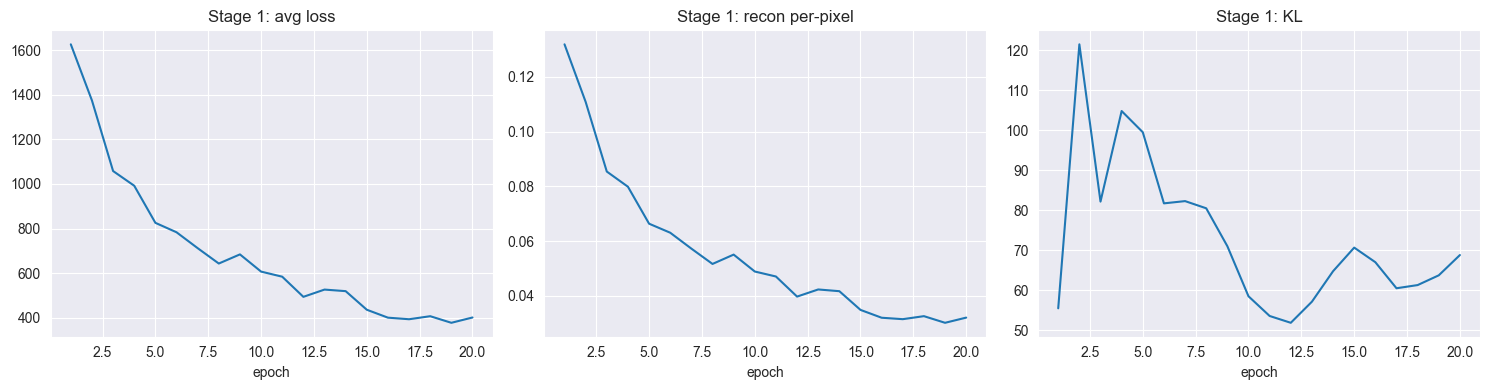

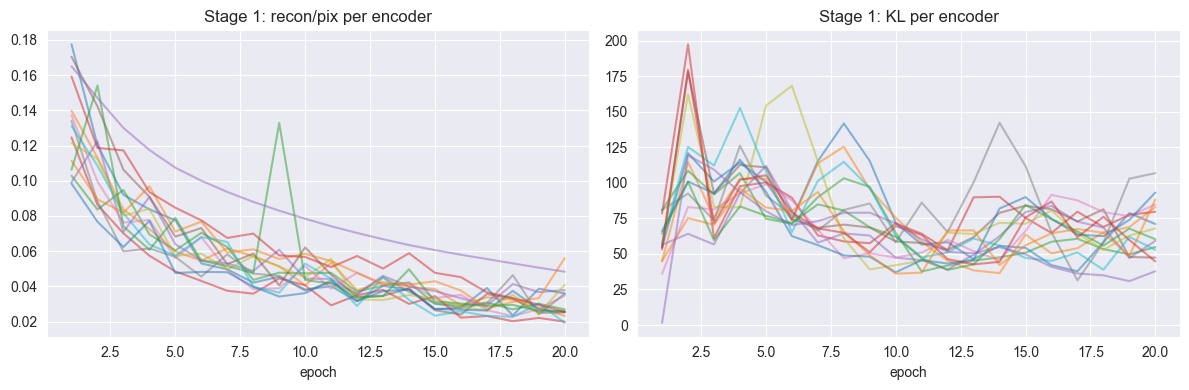

In [8]:
# -------------------- plots: Stage 1 curves --------------------
# Average across encoders (k) per epoch to get a quick signal of learning stability.

import pandas as pd

df1 = pd.DataFrame(stage1_logs)
df1_agg = df1.groupby('epoch').agg({
    'loss': 'mean',
    'recon_per_pix': 'mean',
    'kl': 'mean',
}).reset_index()

def plot_stage1():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(df1_agg['epoch'], df1_agg['loss'])
    axes[0].set_title('Stage 1: avg loss')
    axes[0].set_xlabel('epoch')

    axes[1].plot(df1_agg['epoch'], df1_agg['recon_per_pix'])
    axes[1].set_title('Stage 1: recon per-pixel')
    axes[1].set_xlabel('epoch')

    axes[2].plot(df1_agg['epoch'], df1_agg['kl'])
    axes[2].set_title('Stage 1: KL')
    axes[2].set_xlabel('epoch')

    plt.tight_layout()
    plt.show()

plot_stage1()

# Optional: show per-encoder curves (small K only)
if K <= 25:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for k in range(K):
        d = df1[df1['k'] == k]
        axes[0].plot(d['epoch'], d['recon_per_pix'], alpha=0.5)
        axes[1].plot(d['epoch'], d['kl'], alpha=0.5)
    axes[0].set_title('Stage 1: recon/pix per encoder')
    axes[1].set_title('Stage 1: KL per encoder')
    axes[0].set_xlabel('epoch')
    axes[1].set_xlabel('epoch')
    plt.tight_layout()
    plt.show()



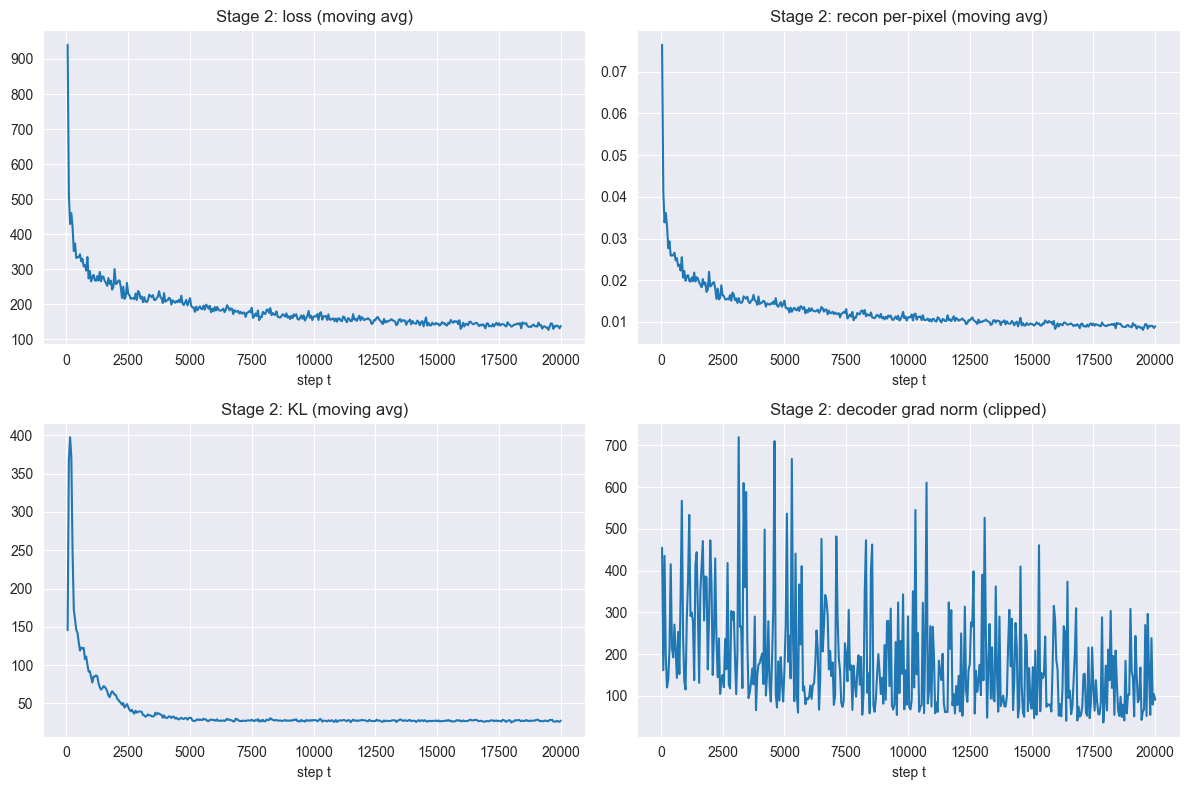

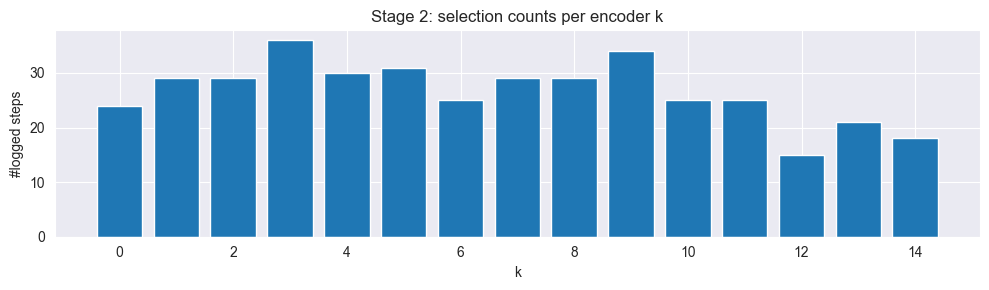

In [9]:
# -------------------- plots: Stage 2 curves --------------------
df2 = pd.DataFrame(stage2_logs)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

axes[0].plot(df2['t'], df2['loss'])
axes[0].set_title('Stage 2: loss (moving avg)')
axes[0].set_xlabel('step t')

axes[1].plot(df2['t'], df2['recon_per_pix'])
axes[1].set_title('Stage 2: recon per-pixel (moving avg)')
axes[1].set_xlabel('step t')

axes[2].plot(df2['t'], df2['kl'])
axes[2].set_title('Stage 2: KL (moving avg)')
axes[2].set_xlabel('step t')

axes[3].plot(df2['t'], df2['grad_norm'])
axes[3].set_title('Stage 2: decoder grad norm (clipped)')
axes[3].set_xlabel('step t')

plt.tight_layout()
plt.show()

# Sanity: how often each encoder was selected
counts = df2['k'].value_counts().sort_index()
plt.figure(figsize=(10,3))
plt.bar(counts.index.astype(int), counts.values)
plt.title('Stage 2: selection counts per encoder k')
plt.xlabel('k')
plt.ylabel('#logged steps')
plt.tight_layout()
plt.show()



In [10]:
# -------------------- export logs (so we can debug even if plots aren't embedded) --------------------
from pathlib import Path
import pandas as pd

out_dir = Path('notebooks/_dp2vae_debug')
out_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame(stage1_logs).to_csv(out_dir / 'stage1_logs.csv', index=False)
pd.DataFrame(stage2_logs).to_csv(out_dir / 'stage2_logs.csv', index=False)

print('[OK] wrote logs to:')
print(' -', out_dir / 'stage1_logs.csv')
print(' -', out_dir / 'stage2_logs.csv')

# quick numeric sanity summaries
if len(stage2_logs.get('t', [])):
    df2 = pd.DataFrame(stage2_logs)
    print('\n[Stage 2 summary: last 10 logged points]')
    print(df2.tail(10)[['t','loss','recon_per_pix','kl','grad_norm','sigma']])



[OK] wrote logs to:
 - notebooks/_dp2vae_debug/stage1_logs.csv
 - notebooks/_dp2vae_debug/stage2_logs.csv

[Stage 2 summary: last 10 logged points]
         t        loss  recon_per_pix         kl   grad_norm  sigma
390  19550  135.216221       0.008690  28.430061   67.523499    0.3
391  19600  144.904251       0.009496  28.220121  269.946381    0.3
392  19650  143.990924       0.009382  28.701872   51.990681    0.3
393  19700  129.348728       0.008378  26.399458  296.409149    0.3
394  19750  137.863783       0.009078  26.316392  157.316116    0.3
395  19800  135.861176       0.008919  26.259789   54.485977    0.3
396  19850  138.963012       0.009093  27.232801  238.227982    0.3
397  19900  136.700338       0.008966  26.524611   79.304367    0.3
398  19950  130.942956       0.008537  26.043832  104.172729    0.3
399  20000  137.712278       0.008964  27.563161   90.729736    0.3
